# Machine Learning - Final Project - Diabetic Classification
## Modeling
### John Chester

---
## Step 1 — Setup & Data Loading

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR   = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

FEATURE_COLS = [
    "_RFHYPE5", "TOLDHI2", "_CHOLCHK", "_BMI5", "SMOKE100",
    "_TOTINDA", "_FRTLT1", "_VEGLT1", "_RFDRHV5", "CVDSTRK3",
    "_MICHD", "HLTHPLN1", "MEDCOST", "GENHLTH", "MENTHLTH",
    "PHYSHLTH", "DIFFWALK", "SEX", "_AGEG5YR", "EDUCA", "INCOME2",
]
TARGET = "Diabetes_binary"

train_df     = pd.read_csv(DATA_DIR / "train.csv")
train_bal_df = pd.read_csv(DATA_DIR / "train_balanced.csv")
test_df      = pd.read_csv(DATA_DIR / "test.csv")

X_train     = train_df[FEATURE_COLS].astype(float)
y_train     = train_df[TARGET].astype(int)

X_train_bal = train_bal_df[FEATURE_COLS].astype(float)
y_train_bal = train_bal_df[TARGET].astype(int)

X_test      = test_df[FEATURE_COLS].astype(float)
y_test      = test_df[TARGET].astype(int)

print(f"X_train     : {X_train.shape}   diabetes rate: {y_train.mean():.3f}")
print(f"X_train_bal : {X_train_bal.shape}   diabetes rate: {y_train_bal.mean():.3f}")
print(f"X_test      : {X_test.shape}   diabetes rate: {y_test.mean():.3f}")

X_train     : (202944, 21)   diabetes rate: 0.158
X_train_bal : (63964, 21)   diabetes rate: 0.500
X_test      : (50736, 21)   diabetes rate: 0.158


---
## Step 2 — Feature Scaling

`StandardScaler` is fit **only on `X_train`** (full natural-distribution training set) and then
applied to all other splits. This prevents any test-set information from leaking into the scaler.

In [107]:
scaler = StandardScaler()
scaler.fit(X_train)   # fit on full natural-distribution training set only

X_train_scaled     = scaler.transform(X_train)
X_train_bal_scaled = scaler.transform(X_train_bal)
X_test_scaled      = scaler.transform(X_test)

assert X_train_scaled.shape[1] == len(FEATURE_COLS), "Scaler output width mismatch"
print("Scaler fit on X_train. Transforms applied to all splits.")
print(f"  X_train_scaled     : {X_train_scaled.shape}")
print(f"  X_train_bal_scaled : {X_train_bal_scaled.shape}")
print(f"  X_test_scaled      : {X_test_scaled.shape}")

Scaler fit on X_train. Transforms applied to all splits.
  X_train_scaled     : (202944, 21)
  X_train_bal_scaled : (63964, 21)
  X_test_scaled      : (50736, 21)


---
## Step 3 — Logistic Regression

L2-penalized logistic regression (sklearn default) with `class_weight='balanced'` to compensate
for the ~84/16 class imbalance. `C` is tuned via 5-fold stratified CV scored on ROC-AUC.

In [108]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    LogisticRegression(class_weight="balanced",
                       solver="lbfgs", max_iter=1000),
    param_grid={"C": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
print(f"Best C       : {lr_grid.best_params_['C']}")
print(f"Best CV AUC  : {lr_grid.best_score_:.4f}")

lr_probs = best_lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = best_lr.predict(X_test_scaled)
lr_auc   = roc_auc_score(y_test, lr_probs)

print(f"\nTest ROC-AUC : {lr_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, lr_preds, target_names=["No diabetes", "Diabetes"]))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C       : 0.001
Best CV AUC  : 0.8178

Test ROC-AUC : 0.8177

Classification report:
              precision    recall  f1-score   support

 No diabetes       0.94      0.73      0.82     42741
    Diabetes       0.34      0.76      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.65     50736
weighted avg       0.85      0.73      0.76     50736



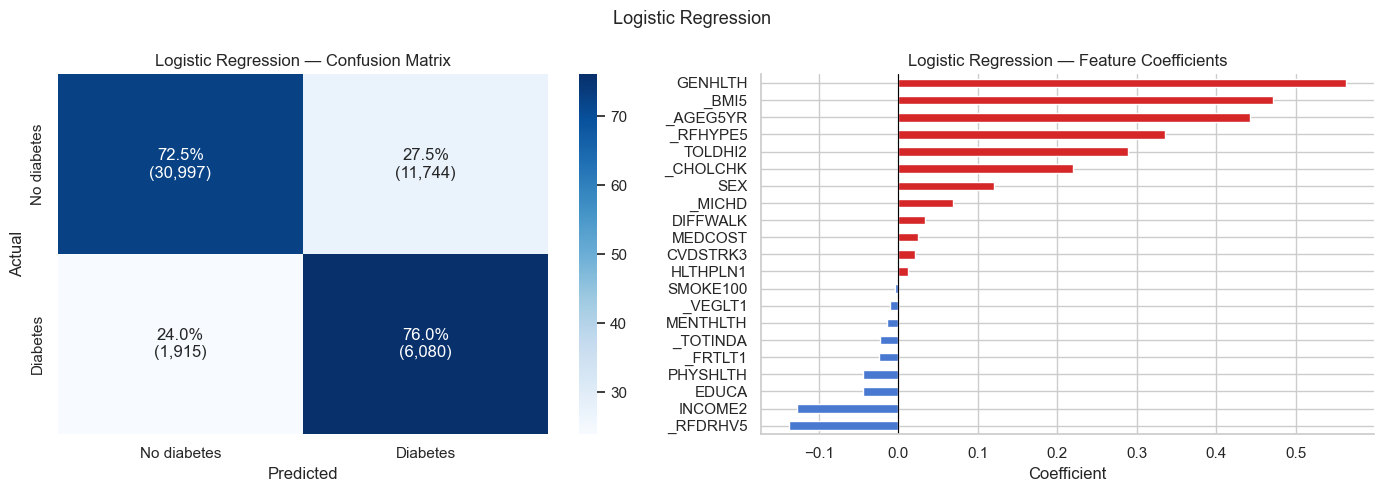

In [109]:
# LR: confusion matrix + feature coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, lr_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_pct, annot=np.array([[f"{v:.1f}%\n({c:,})" for v, c in zip(row_p, row_c)]
                             for row_p, row_c in zip(cm_pct, cm)]),
    fmt="", cmap="Blues", ax=axes[0],
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"],
)
axes[0].set_title("Logistic Regression — Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Feature coefficients
coef = best_lr.coef_[0]
feat_df = pd.Series(coef, index=FEATURE_COLS).sort_values()
colors = ["#d62728" if v > 0 else "#4878cf" for v in feat_df]
feat_df.plot.barh(ax=axes[1], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Logistic Regression — Feature Coefficients")
axes[1].set_xlabel("Coefficient")
for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.suptitle("Logistic Regression", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_lr_confusion_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Step 4 — Linear SVM

`LinearSVC` on the 50/50 balanced training set. Wrapped in `CalibratedClassifierCV` to produce
probability outputs needed for ROC-AUC. `C` tuned via 5-fold CV.

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C       : 0.01
Best CV AUC  : 0.8156

Test ROC-AUC : 0.8175

Classification report:
              precision    recall  f1-score   support

 No diabetes       0.94      0.73      0.82     42741
    Diabetes       0.34      0.76      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.73      0.76     50736



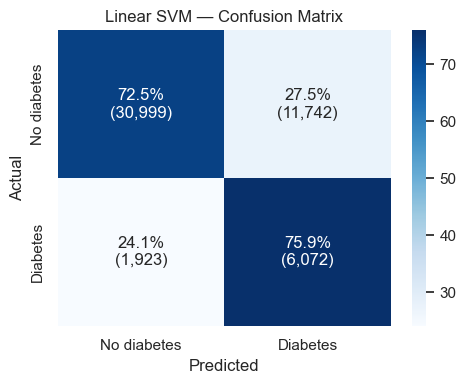

In [110]:
lsvm_grid = GridSearchCV(
    CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=5000), cv=3
    ),
    param_grid={"estimator__C": [0.001, 0.01, 0.1, 1, 10]},
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
lsvm_grid.fit(X_train_bal_scaled, y_train_bal)

best_lsvm = lsvm_grid.best_estimator_
print(f"Best C       : {lsvm_grid.best_params_['estimator__C']}")
print(f"Best CV AUC  : {lsvm_grid.best_score_:.4f}")

lsvm_probs = best_lsvm.predict_proba(X_test_scaled)[:, 1]
lsvm_preds = best_lsvm.predict(X_test_scaled)
lsvm_auc   = roc_auc_score(y_test, lsvm_probs)

print(f"\nTest ROC-AUC : {lsvm_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, lsvm_preds, target_names=["No diabetes", "Diabetes"]))

# Confusion matrix
cm = confusion_matrix(y_test, lsvm_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_pct, annot=np.array([[f"{v:.1f}%\n({c:,})" for v, c in zip(row_p, row_c)]
                             for row_p, row_c in zip(cm_pct, cm)]),
    fmt="", cmap="Blues", ax=ax,
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"],
)
ax.set_title("Linear SVM — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_lsvm_confusion.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Step 5 — Kernel SVM (RBF)

`SVC(kernel='rbf')` builds an n×n kernel matrix; at 63K rows that exceeds available memory.
We subsample 20,000 rows from the balanced training set (representative given 50/50 classes).
`C` and `gamma` are tuned jointly via 5-fold CV.

RBF SVM subsample : (20000, 21)  class balance: 0.502
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params  : {'C': 1, 'gamma': 0.01}
Best CV AUC  : 0.8185

Test ROC-AUC : 0.8205

Classification report:
              precision    recall  f1-score   support

 No diabetes       0.95      0.68      0.79     42741
    Diabetes       0.32      0.81      0.46      7995

    accuracy                           0.70     50736
   macro avg       0.64      0.75      0.63     50736
weighted avg       0.85      0.70      0.74     50736



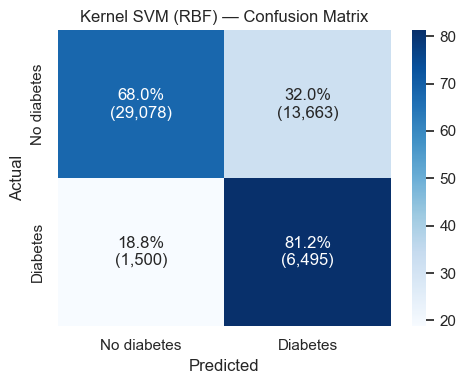

In [111]:
rng = np.random.default_rng(42)
sub_idx = rng.choice(len(X_train_bal_scaled), size=20_000, replace=False)
X_sub = X_train_bal_scaled[sub_idx]
y_sub = y_train_bal.iloc[sub_idx].values

print(f"RBF SVM subsample : {X_sub.shape}  class balance: {y_sub.mean():.3f}")

ksvm_grid = GridSearchCV(
    SVC(kernel="rbf", class_weight="balanced", probability=True),
    param_grid={"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]},
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
ksvm_grid.fit(X_sub, y_sub)

best_ksvm = ksvm_grid.best_estimator_
print(f"Best params  : {ksvm_grid.best_params_}")
print(f"Best CV AUC  : {ksvm_grid.best_score_:.4f}")

ksvm_probs = best_ksvm.predict_proba(X_test_scaled)[:, 1]
ksvm_preds = best_ksvm.predict(X_test_scaled)
ksvm_auc   = roc_auc_score(y_test, ksvm_probs)

print(f"\nTest ROC-AUC : {ksvm_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, ksvm_preds, target_names=["No diabetes", "Diabetes"]))

# Confusion matrix
cm = confusion_matrix(y_test, ksvm_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_pct, annot=np.array([[f"{v:.1f}%\n({c:,})" for v, c in zip(row_p, row_c)]
                             for row_p, row_c in zip(cm_pct, cm)]),
    fmt="", cmap="Blues", ax=ax,
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"],
)
ax.set_title("Kernel SVM (RBF) — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_ksvm_confusion.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Step 6 — Neural Network (PyTorch MLP)

A configurable `nn.Module` MLP using `nn.Linear` layers. Architecture and L2 regularization
strength are searched via a grid; the best config is identified by validation ROC-AUC and then
refit on the full natural-distribution training set for final evaluation.

In [112]:
from sklearn.metrics import fbeta_score

class MLP(nn.Module):
    def __init__(self, in_features, hidden_sizes, dropout=0.3):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))  # raw logit; sigmoid applied at inference
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_mlp(X_tr, y_tr, X_val, y_val,
              hidden_sizes, weight_decay,
              optimizer_cls=torch.optim.Adam,
              lr=1e-3,
              pos_weight=None,
              max_epochs=50, patience=15, batch_size=256,
              ckpt="_best_mlp.pt",
              monitor="val_auc"):
    """
    monitor: metric used for early stopping, checkpointing, and LR scheduling.
      "val_auc" — ROC-AUC; threshold-independent, good for arch/wd search.
      "val_f2"  — F2 score (beta=2); weights recall 2x precision at threshold 0.5.
                  Use when tuning pos_weight so the search directly optimises recall.

    ReduceLROnPlateau halves the LR after 5 non-improving epochs (scheduler_patience),
    giving the model a chance to fine-tune from each plateau before the hard early-stop
    patience of 15 fires. This allows up to ~2 LR reductions per run before quitting.
    """
    assert monitor in ("val_auc", "val_f2"), f"Unknown monitor: {monitor}"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=batch_size, shuffle=True)

    model     = MLP(X_tr.shape[1], hidden_sizes).to(device)
    pw        = torch.tensor([pos_weight], device=device) if pos_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-6,
    )

    history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f2": []}
    best_monitor_val = -1.0
    patience_counter = 0
    best_epoch       = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(device)).cpu()
            val_loss   = criterion(val_logits, y_val_t).item()
            val_probs  = torch.sigmoid(val_logits).numpy()
        val_preds = (val_probs >= 0.5).astype(int)
        val_auc   = roc_auc_score(y_val, val_probs)
        val_f2    = fbeta_score(y_val, val_preds, beta=2, zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)
        history["val_f2"].append(val_f2)

        current    = val_auc if monitor == "val_auc" else val_f2
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(current)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{max_epochs} | train_loss={train_loss:.4f} | "
                  f"val_auc={val_auc:.4f} | val_f2={val_f2:.4f} | lr={current_lr:.2e}")

        if current > best_monitor_val:
            best_monitor_val = current
            best_epoch       = epoch
            torch.save(model.state_dict(), ckpt)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop at epoch {epoch} (best epoch {best_epoch}, "
                      f"best {monitor}={best_monitor_val:.4f})")
                break

    model.load_state_dict(torch.load(ckpt, weights_only=True))
    return model, history, best_epoch


print("train_mlp defined — ReduceLROnPlateau (patience=5, factor=0.5), hard stop patience=15.")

train_mlp defined — ReduceLROnPlateau (patience=5, factor=0.5), hard stop patience=15.


In [113]:
from sklearn.model_selection import train_test_split as sk_split

# Stratified 90/10 split from the FULL training set
# Stratification preserves the natural 84/16 class ratio in the val set
X_tr_s, X_val_s, y_tr_s, y_val_s = sk_split(
    X_train_scaled, y_train.values,
    test_size=0.10, stratify=y_train.values, random_state=42,
)

# Natural pos_weight: penalises FNs enough to offset the 84/16 imbalance
natural_pw = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"Full training set  : {X_tr_s.shape[0]:,} rows")
print(f"Validation set     : {X_val_s.shape[0]:,} rows")
print(f"Natural pos_weight : {natural_pw:.2f}  (neg/pos ratio)")

ARCH_GRID = [(64, 32), (128, 64), (128, 64, 32)]
WD_GRID   = [1e-4, 1e-3, 1e-2]

# Architecture × weight_decay search — Adam, lr=1e-3, pos_weight=natural_pw
search_results = []
for hidden in ARCH_GRID:
    for wd in WD_GRID:
        print(f"\n=== arch={hidden}  wd={wd} ===")
        _, hist, best_ep = train_mlp(
            X_tr_s, y_tr_s, X_val_s, y_val_s,
            hidden_sizes=hidden, weight_decay=wd,
            pos_weight=natural_pw, ckpt="_best_mlp_v1.pt",
        )
        best_val_auc = max(hist["val_auc"])
        search_results.append({
            "hidden_sizes": hidden, "weight_decay": wd,
            "best_val_auc": best_val_auc, "best_epoch": best_ep,
        })
        print(f"  >> best val AUC = {best_val_auc:.4f}  (epoch {best_ep})")

results_df = pd.DataFrame(search_results).sort_values("best_val_auc", ascending=False)
print("\n--- NN v1 architecture search results ---")
print(results_df.to_string(index=False))

Full training set  : 182,649 rows
Validation set     : 20,295 rows
Natural pos_weight : 5.35  (neg/pos ratio)

=== arch=(64, 32)  wd=0.0001 ===
  Epoch  10/50 | train_loss=0.8687 | val_auc=0.8262 | val_f2=0.6198 | lr=1.00e-03
  Epoch  20/50 | train_loss=0.8633 | val_auc=0.8262 | val_f2=0.6172 | lr=2.50e-04
  Early stop at epoch 28 (best epoch 13, best val_auc=0.8266)
  >> best val AUC = 0.8266  (epoch 13)

=== arch=(64, 32)  wd=0.001 ===
  Epoch  10/50 | train_loss=0.8700 | val_auc=0.8251 | val_f2=0.6169 | lr=1.00e-03
  Epoch  20/50 | train_loss=0.8690 | val_auc=0.8251 | val_f2=0.6145 | lr=1.00e-03
  Epoch  30/50 | train_loss=0.8651 | val_auc=0.8259 | val_f2=0.6178 | lr=2.50e-04
  Epoch  40/50 | train_loss=0.8633 | val_auc=0.8262 | val_f2=0.6168 | lr=1.25e-04
  Epoch  50/50 | train_loss=0.8646 | val_auc=0.8262 | val_f2=0.6186 | lr=3.13e-05
  >> best val AUC = 0.8262  (epoch 44)

=== arch=(64, 32)  wd=0.01 ===
  Epoch  10/50 | train_loss=0.8775 | val_auc=0.8229 | val_f2=0.6188 | lr=1.00

In [114]:
best_row    = results_df.iloc[0]
best_hidden = best_row["hidden_sizes"]
best_wd     = best_row["weight_decay"]
print(f"Best v1 config: arch={best_hidden}  wd={best_wd}  pos_weight={natural_pw:.2f}")

final_mlp, final_history, final_best_ep = train_mlp(
    X_tr_s, y_tr_s, X_val_s, y_val_s,
    hidden_sizes=best_hidden, weight_decay=best_wd,
    pos_weight=natural_pw, ckpt="_best_mlp_v1.pt",
)
print(f"Final model stopped at epoch {final_best_ep}")

Best v1 config: arch=(64, 32)  wd=0.0001  pos_weight=5.35
  Epoch  10/50 | train_loss=0.8689 | val_auc=0.8259 | val_f2=0.6212 | lr=1.00e-03
  Epoch  20/50 | train_loss=0.8645 | val_auc=0.8259 | val_f2=0.6192 | lr=1.00e-03
  Epoch  30/50 | train_loss=0.8620 | val_auc=0.8259 | val_f2=0.6185 | lr=2.50e-04
  Epoch  40/50 | train_loss=0.8599 | val_auc=0.8259 | val_f2=0.6175 | lr=6.25e-05
  Early stop at epoch 41 (best epoch 26, best val_auc=0.8262)
Final model stopped at epoch 26


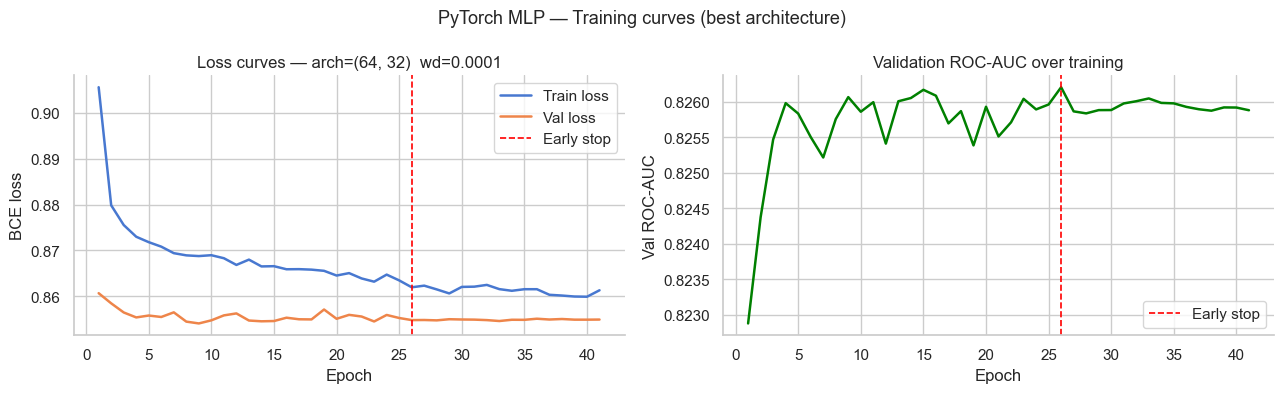

In [115]:
# Training curves for the best architecture
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(final_history["train_loss"]) + 1)

ax1.plot(epochs, final_history["train_loss"], label="Train loss", linewidth=1.8)
ax1.plot(epochs, final_history["val_loss"],   label="Val loss",   linewidth=1.8)
ax1.axvline(final_best_ep, color="red", linestyle="--", linewidth=1.2, label="Early stop")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE loss")
ax1.set_title(f"Loss curves — arch={best_hidden}  wd={best_wd}")
ax1.legend()
for spine in ["top", "right"]: ax1.spines[spine].set_visible(False)

ax2.plot(epochs, final_history["val_auc"], color="green", linewidth=1.8)
ax2.axvline(final_best_ep, color="red", linestyle="--", linewidth=1.2, label="Early stop")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val ROC-AUC")
ax2.set_title("Validation ROC-AUC over training")
ax2.legend()
for spine in ["top", "right"]: ax2.spines[spine].set_visible(False)

plt.suptitle("PyTorch MLP — Training curves (best architecture)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "14_mlp_v1_training_curves.png", bbox_inches="tight", dpi=150)
plt.show()

Test ROC-AUC : 0.8249

Classification report:
              precision    recall  f1-score   support

 No diabetes       0.95      0.71      0.81     42741
    Diabetes       0.34      0.79      0.47      7995

    accuracy                           0.72     50736
   macro avg       0.64      0.75      0.64     50736
weighted avg       0.85      0.72      0.76     50736



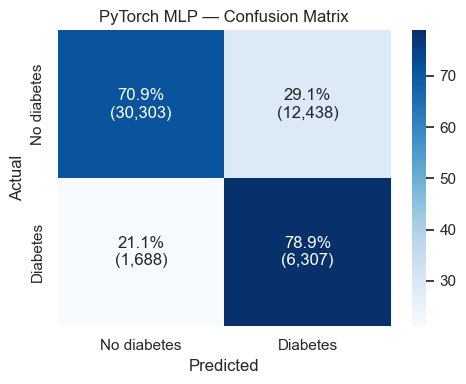

In [116]:
# MLP evaluation on test set
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

final_mlp.eval()
with torch.no_grad():
    nn_logits = final_mlp(X_test_t).cpu()
    nn_probs  = torch.sigmoid(nn_logits).numpy()
    nn_preds  = (nn_probs >= 0.5).astype(int)

nn_auc = roc_auc_score(y_test, nn_probs)
print(f"Test ROC-AUC : {nn_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, nn_preds, target_names=["No diabetes", "Diabetes"]))

assert roc_auc_score(y_test, nn_probs) > 0.5, "NN AUC below chance"

# Confusion matrix
cm = confusion_matrix(y_test, nn_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_pct, annot=np.array([[f"{v:.1f}%\n({c:,})" for v, c in zip(row_p, row_c)]
                             for row_p, row_c in zip(cm_pct, cm)]),
    fmt="", cmap="Blues", ax=ax,
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"],
)
ax.set_title("PyTorch MLP — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_mlp_v1_confusion.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Step 7 — Individual ROC Curves

ROC curve for each model plotted individually, then overlaid in Step 8.

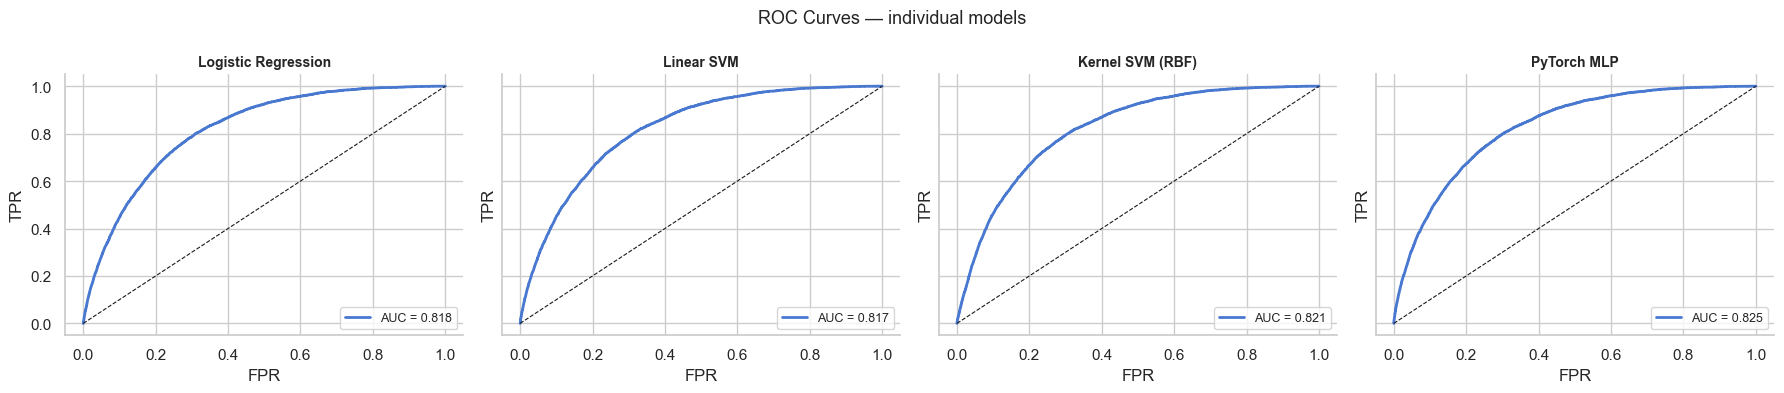

All models pass AUC > 0.5 sanity check.


In [117]:
models_eval = [
    ("Logistic Regression", lr_probs,   lr_auc),
    ("Linear SVM",          lsvm_probs, lsvm_auc),
    ("Kernel SVM (RBF)",    ksvm_probs, ksvm_auc),
    ("PyTorch MLP",         nn_probs,   nn_auc),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, (name, probs, auc) in zip(axes, models_eval):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(loc="lower right", fontsize=9)
    for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

plt.suptitle("ROC Curves — individual models", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_roc_curves_individual.png", bbox_inches="tight", dpi=150)
plt.show()

# Sanity checks
for name, probs, auc in models_eval:
    assert auc > 0.5, f"{name} AUC below chance: {auc:.4f}"
print("All models pass AUC > 0.5 sanity check.")

---
## Step 8 — Model Comparison

All four ROC curves overlaid on a single plot, followed by a summary metrics table.

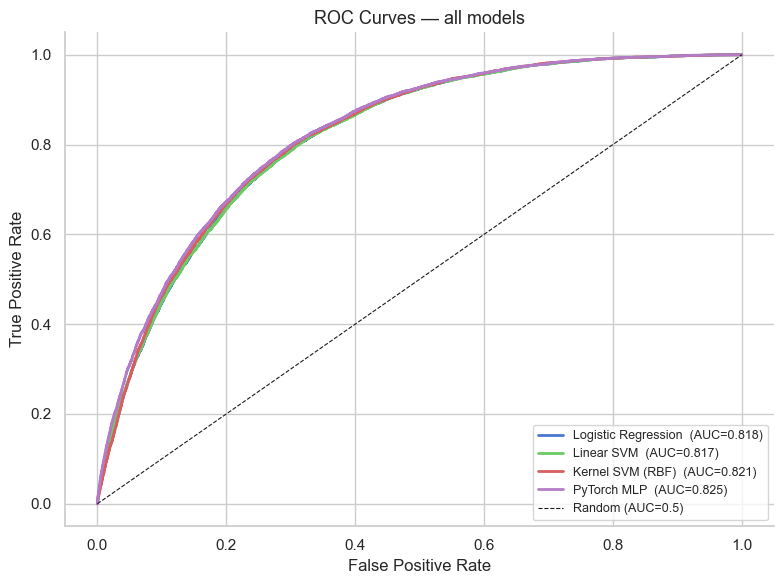

Model comparison (minority class = Diabetes):
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression    0.7308     0.3411  0.7605 0.4710   0.8177
Linear SVM             0.7307     0.3409  0.7595 0.4705   0.8175
Kernel SVM (RBF)       0.7011     0.3222  0.8124 0.4614   0.8205
PyTorch MLP            0.7216     0.3365  0.7889 0.4717   0.8249


In [118]:
colors = ["#4878cf", "#6acc65", "#d65f5f", "#b47cc7"]

fig, ax = plt.subplots(figsize=(8, 6))
for (name, probs, auc), color in zip(models_eval, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name}  (AUC={auc:.3f})", color=color)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — all models", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "17_roc_curves_all_models.png", bbox_inches="tight", dpi=150)
plt.show()

# Summary metrics table
rows = []
preds_map = {
    "Logistic Regression": lr_preds,
    "Linear SVM":          lsvm_preds,
    "Kernel SVM (RBF)":    ksvm_preds,
    "PyTorch MLP":         nn_preds,
}
for name, probs, auc in models_eval:
    preds = preds_map[name]
    rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall":    recall_score(y_test, preds),
        "F1":        f1_score(y_test, preds),
        "ROC-AUC":   auc,
    })

summary = pd.DataFrame(rows).set_index("Model")
print("Model comparison (minority class = Diabetes):")
print(summary.round(4).to_string())

---
## Step 9 — NN Iteration 2: AdamW + Lower Learning Rate

Two changes applied on top of the full-dataset baseline:
- **`AdamW`** — decouples weight decay from adaptive gradient scaling (Adam conflates the two,
  undermining L2 regularisation; AdamW fixes this)
- **`lr=5e-4`** — half the original rate; allows finer updates so later epochs contribute before
  early stopping triggers

`pos_weight` is held fixed at the natural class ratio (~5.33) — same as v1 — so only the
optimiser and learning rate vary. Same architecture × weight_decay grid for a fair comparison.

In [119]:
# train_mlp (defined in Step 6) now accepts optimizer_cls, lr, pos_weight, and ckpt.
# All three NN runs use it with different arguments — no separate function needed.
print("Using train_mlp with AdamW + lr=5e-4 + pos_weight=natural_pw for v2.")

Using train_mlp with AdamW + lr=5e-4 + pos_weight=natural_pw for v2.


In [120]:
# Architecture × weight_decay search — AdamW, lr=5e-4, pos_weight=natural_pw
search_v2 = []
for hidden in ARCH_GRID:
    for wd in WD_GRID:
        print(f"\n=== arch={hidden}  wd={wd} ===")
        _, hist, best_ep = train_mlp(
            X_tr_s, y_tr_s, X_val_s, y_val_s,
            hidden_sizes=hidden, weight_decay=wd,
            optimizer_cls=torch.optim.AdamW, lr=5e-4,
            pos_weight=natural_pw, ckpt="_best_mlp_v2.pt",
        )
        best_val_auc = max(hist["val_auc"])
        search_v2.append({
            "hidden_sizes": hidden, "weight_decay": wd,
            "best_val_auc": best_val_auc, "best_epoch": best_ep,
        })
        print(f"  >> best val AUC = {best_val_auc:.4f}  (epoch {best_ep})")

results_v2 = pd.DataFrame(search_v2).sort_values("best_val_auc", ascending=False)
print("\n--- NN v2 architecture search results ---")
print(results_v2.to_string(index=False))


=== arch=(64, 32)  wd=0.0001 ===
  Epoch  10/50 | train_loss=0.8702 | val_auc=0.8263 | val_f2=0.6169 | lr=5.00e-04
  Epoch  20/50 | train_loss=0.8651 | val_auc=0.8262 | val_f2=0.6192 | lr=5.00e-04
  Epoch  30/50 | train_loss=0.8632 | val_auc=0.8262 | val_f2=0.6189 | lr=1.25e-04
  Early stop at epoch 32 (best epoch 17, best val_auc=0.8266)
  >> best val AUC = 0.8266  (epoch 17)

=== arch=(64, 32)  wd=0.001 ===
  Epoch  10/50 | train_loss=0.8690 | val_auc=0.8260 | val_f2=0.6198 | lr=5.00e-04
  Epoch  20/50 | train_loss=0.8643 | val_auc=0.8260 | val_f2=0.6168 | lr=2.50e-04
  Early stop at epoch 28 (best epoch 13, best val_auc=0.8263)
  >> best val AUC = 0.8263  (epoch 13)

=== arch=(64, 32)  wd=0.01 ===
  Epoch  10/50 | train_loss=0.8686 | val_auc=0.8258 | val_f2=0.6104 | lr=5.00e-04
  Epoch  20/50 | train_loss=0.8654 | val_auc=0.8260 | val_f2=0.6127 | lr=1.25e-04
  Early stop at epoch 20 (best epoch 5, best val_auc=0.8261)
  >> best val AUC = 0.8261  (epoch 5)

=== arch=(128, 64)  wd=0.

Best v2 config: arch=(128, 64, 32)  wd=0.01  pos_weight=5.35
  Epoch  10/50 | train_loss=0.8684 | val_auc=0.8266 | val_f2=0.6157 | lr=5.00e-04
  Epoch  20/50 | train_loss=0.8624 | val_auc=0.8262 | val_f2=0.6200 | lr=2.50e-04
  Early stop at epoch 25 (best epoch 10, best val_auc=0.8266)

Test ROC-AUC (v2) : 0.8250

Classification report:
              precision    recall  f1-score   support

 No diabetes       0.95      0.71      0.81     42741
    Diabetes       0.34      0.79      0.47      7995

    accuracy                           0.72     50736
   macro avg       0.64      0.75      0.64     50736
weighted avg       0.85      0.72      0.76     50736



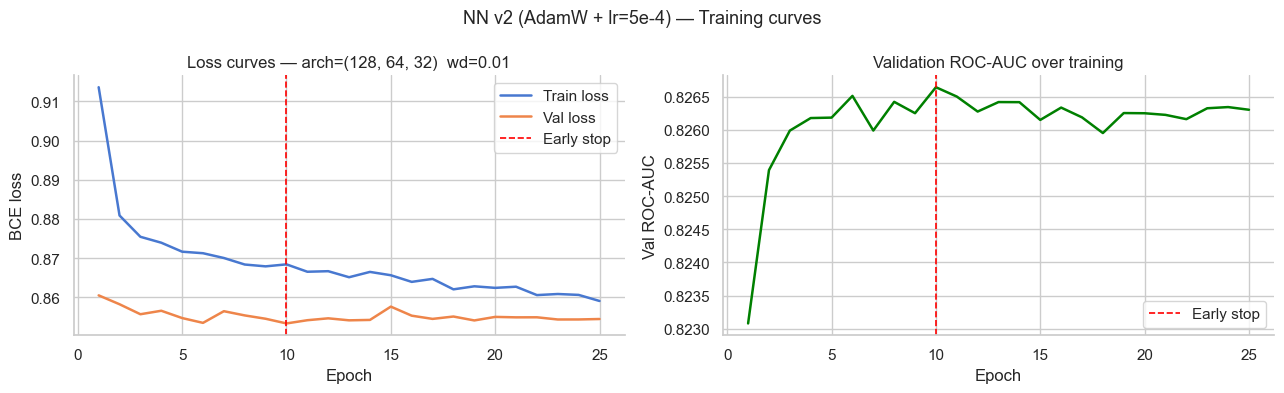

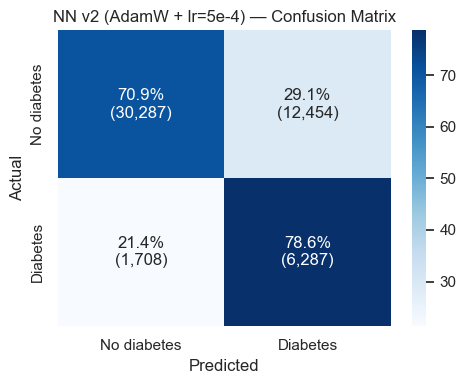

In [121]:
best_v2      = results_v2.iloc[0]
best_v2_arch = best_v2["hidden_sizes"]
best_v2_wd   = best_v2["weight_decay"]
print(f"Best v2 config: arch={best_v2_arch}  wd={best_v2_wd}  pos_weight={natural_pw:.2f}")

nn_v2, hist_v2, ep_v2 = train_mlp(
    X_tr_s, y_tr_s, X_val_s, y_val_s,
    hidden_sizes=best_v2_arch, weight_decay=best_v2_wd,
    optimizer_cls=torch.optim.AdamW, lr=5e-4,
    pos_weight=natural_pw, ckpt="_best_mlp_v2.pt",
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

nn_v2.eval()
with torch.no_grad():
    nn_v2_probs = torch.sigmoid(nn_v2(X_test_t).cpu()).numpy()
nn_v2_preds = (nn_v2_probs >= 0.5).astype(int)
nn_v2_auc   = roc_auc_score(y_test, nn_v2_probs)

print(f"\nTest ROC-AUC (v2) : {nn_v2_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, nn_v2_preds, target_names=["No diabetes", "Diabetes"]))

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_v2 = range(1, len(hist_v2["train_loss"]) + 1)

ax1.plot(epochs_v2, hist_v2["train_loss"], label="Train loss", linewidth=1.8)
ax1.plot(epochs_v2, hist_v2["val_loss"],   label="Val loss",   linewidth=1.8)
ax1.axvline(ep_v2, color="red", linestyle="--", linewidth=1.2, label="Early stop")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE loss")
ax1.set_title(f"Loss curves — arch={best_v2_arch}  wd={best_v2_wd}")
ax1.legend()
for spine in ["top", "right"]: ax1.spines[spine].set_visible(False)

ax2.plot(epochs_v2, hist_v2["val_auc"], color="green", linewidth=1.8)
ax2.axvline(ep_v2, color="red", linestyle="--", linewidth=1.2, label="Early stop")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val ROC-AUC")
ax2.set_title("Validation ROC-AUC over training")
ax2.legend()
for spine in ["top", "right"]: ax2.spines[spine].set_visible(False)

plt.suptitle("NN v2 (AdamW + lr=5e-4) — Training curves", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "18_mlp_v2_training_curves.png", bbox_inches="tight", dpi=150)
plt.show()

cm = confusion_matrix(y_test, nn_v2_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_pct, annot=np.array([[f"{v:.1f}%\n({c:,})" for v, c in zip(row_p, row_c)]
                             for row_p, row_c in zip(cm_pct, cm)]),
    fmt="", cmap="Blues", ax=ax,
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"],
)
ax.set_title("NN v2 (AdamW + lr=5e-4) — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "19_mlp_v2_confusion.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Step 10 — NN Iteration 3: AdamW + Lower LR + Tuned `pos_weight`

The natural class ratio (`pos_weight ≈ 5.35`) makes the model treat each positive example as
equally informative as ~5 negatives, approximately restoring balance. Here we search above and
below that value to explicitly trade precision for recall — the medically motivated direction.

- Values **below** `natural_pw` under-correct for imbalance → more FNs
- Values **at** `natural_pw` restore balance with no extra FN penalty
- Values **above** `natural_pw` aggressively penalise FNs → higher recall, lower precision

Architecture and weight_decay are fixed to the best config from v2.

In [122]:
PW_GRID = [2.0, natural_pw, natural_pw * 1.5, natural_pw * 2.0, natural_pw * 3.0]
PW_GRID = [round(w, 2) for w in PW_GRID]
print(f"pos_weight search grid: {PW_GRID}")
print(f"Monitoring: val_f2 (beta=2) — directly optimises recall over precision\n")

search_v3 = []
for pw in PW_GRID:
    print(f"\n=== pos_weight={pw:.2f} ===")
    _, hist, best_ep = train_mlp(
        X_tr_s, y_tr_s, X_val_s, y_val_s,
        hidden_sizes=best_v2_arch, weight_decay=best_v2_wd,
        optimizer_cls=torch.optim.AdamW, lr=5e-4,
        pos_weight=pw, ckpt="_best_mlp_v3.pt",
        monitor="val_f2",
    )
    best_val_f2 = max(hist["val_f2"])
    best_val_auc = hist["val_auc"][best_ep - 1]
    search_v3.append({
        "pos_weight": pw, "best_val_f2": best_val_f2,
        "val_auc_at_best": best_val_auc, "best_epoch": best_ep,
    })
    print(f"  >> best val F2 = {best_val_f2:.4f}  val AUC = {best_val_auc:.4f}  (epoch {best_ep})")

results_v3 = pd.DataFrame(search_v3).sort_values("best_val_f2", ascending=False)
print("\n--- NN v3 pos_weight search results (sorted by val F2) ---")
print(results_v3.to_string(index=False))

pos_weight search grid: [2.0, 5.35, 8.02, 10.69, 16.04]
Monitoring: val_f2 (beta=2) — directly optimises recall over precision


=== pos_weight=2.00 ===
  Epoch  10/50 | train_loss=0.5177 | val_auc=0.8260 | val_f2=0.4641 | lr=5.00e-04
  Epoch  20/50 | train_loss=0.5136 | val_auc=0.8258 | val_f2=0.4708 | lr=2.50e-04
  Early stop at epoch 28 (best epoch 13, best val_f2=0.4973)
  >> best val F2 = 0.4973  val AUC = 0.8258  (epoch 13)

=== pos_weight=5.35 ===
  Epoch  10/50 | train_loss=0.8695 | val_auc=0.8267 | val_f2=0.6174 | lr=5.00e-04
  Early stop at epoch 19 (best epoch 4, best val_f2=0.6227)
  >> best val F2 = 0.6227  val AUC = 0.8262  (epoch 4)

=== pos_weight=8.02 ===
  Epoch  10/50 | train_loss=1.0511 | val_auc=0.8261 | val_f2=0.6271 | lr=5.00e-04
  Epoch  20/50 | train_loss=1.0446 | val_auc=0.8259 | val_f2=0.6266 | lr=1.25e-04
  Early stop at epoch 21 (best epoch 6, best val_f2=0.6293)
  >> best val F2 = 0.6293  val AUC = 0.8261  (epoch 6)

=== pos_weight=10.69 ===
  Epoch  10/50

Best pos_weight: 8.02  (arch=(128, 64, 32)  wd=0.01)
  Epoch  10/50 | train_loss=1.0503 | val_auc=0.8253 | val_f2=0.6244 | lr=5.00e-04
  Epoch  20/50 | train_loss=1.0432 | val_auc=0.8259 | val_f2=0.6270 | lr=2.50e-04
  Early stop at epoch 26 (best epoch 11, best val_f2=0.6284)

Test ROC-AUC (v3) : 0.8244

Classification report:
              precision    recall  f1-score   support

 No diabetes       0.96      0.62      0.76     42741
    Diabetes       0.30      0.86      0.44      7995

    accuracy                           0.66     50736
   macro avg       0.63      0.74      0.60     50736
weighted avg       0.86      0.66      0.71     50736



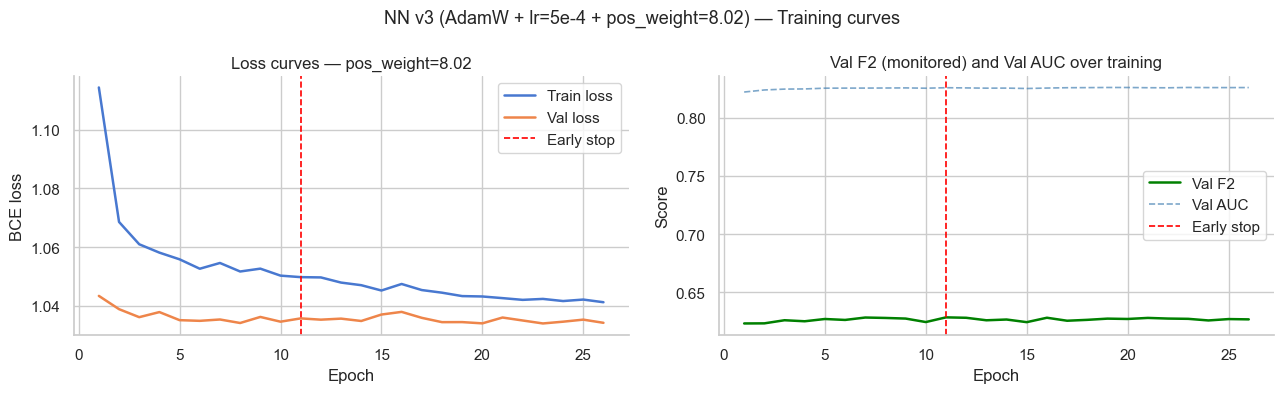

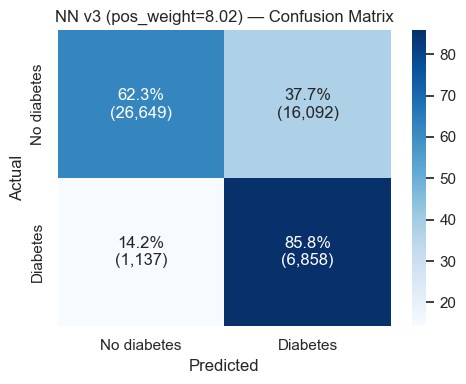

In [123]:
best_pw = results_v3.iloc[0]["pos_weight"]
print(f"Best pos_weight: {best_pw:.2f}  (arch={best_v2_arch}  wd={best_v2_wd})")

nn_v3, hist_v3, ep_v3 = train_mlp(
    X_tr_s, y_tr_s, X_val_s, y_val_s,
    hidden_sizes=best_v2_arch, weight_decay=best_v2_wd,
    optimizer_cls=torch.optim.AdamW, lr=5e-4,
    pos_weight=best_pw, ckpt="_best_mlp_v3.pt",
    monitor="val_f2",
)

nn_v3.eval()
with torch.no_grad():
    nn_v3_probs = torch.sigmoid(nn_v3(X_test_t).cpu()).numpy()
nn_v3_preds = (nn_v3_probs >= 0.5).astype(int)
nn_v3_auc   = roc_auc_score(y_test, nn_v3_probs)

print(f"\nTest ROC-AUC (v3) : {nn_v3_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, nn_v3_preds, target_names=["No diabetes", "Diabetes"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_v3 = range(1, len(hist_v3["train_loss"]) + 1)

ax1.plot(epochs_v3, hist_v3["train_loss"], label="Train loss", linewidth=1.8)
ax1.plot(epochs_v3, hist_v3["val_loss"],   label="Val loss",   linewidth=1.8)
ax1.axvline(ep_v3, color="red", linestyle="--", linewidth=1.2, label="Early stop")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE loss")
ax1.set_title(f"Loss curves — pos_weight={best_pw:.2f}")
ax1.legend()
for spine in ["top", "right"]: ax1.spines[spine].set_visible(False)

ax2.plot(epochs_v3, hist_v3["val_f2"],  color="green",  linewidth=1.8, label="Val F2")
ax2.plot(epochs_v3, hist_v3["val_auc"], color="steelblue", linewidth=1.2,
         linestyle="--", label="Val AUC", alpha=0.7)
ax2.axvline(ep_v3, color="red", linestyle="--", linewidth=1.2, label="Early stop")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.set_title("Val F2 (monitored) and Val AUC over training")
ax2.legend()
for spine in ["top", "right"]: ax2.spines[spine].set_visible(False)

plt.suptitle(f"NN v3 (AdamW + lr=5e-4 + pos_weight={best_pw:.2f}) — Training curves", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "20_mlp_v3_training_curves.png", bbox_inches="tight", dpi=150)
plt.show()

cm = confusion_matrix(y_test, nn_v3_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_pct, annot=np.array([[f"{v:.1f}%\n({c:,})" for v, c in zip(row_p, row_c)]
                             for row_p, row_c in zip(cm_pct, cm)]),
    fmt="", cmap="Blues", ax=ax,
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"],
)
ax.set_title(f"NN v3 (pos_weight={best_pw:.2f}) — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "21_mlp_v3_confusion.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Step 11 — NN Iteration Comparison

Side-by-side view of all three NN variants to isolate the contribution of each change.
The key metric to watch alongside ROC-AUC is **recall on the diabetes class** — the
medical cost of a false negative (missed diagnosis) is substantially higher than a false
positive (unnecessary follow-up).

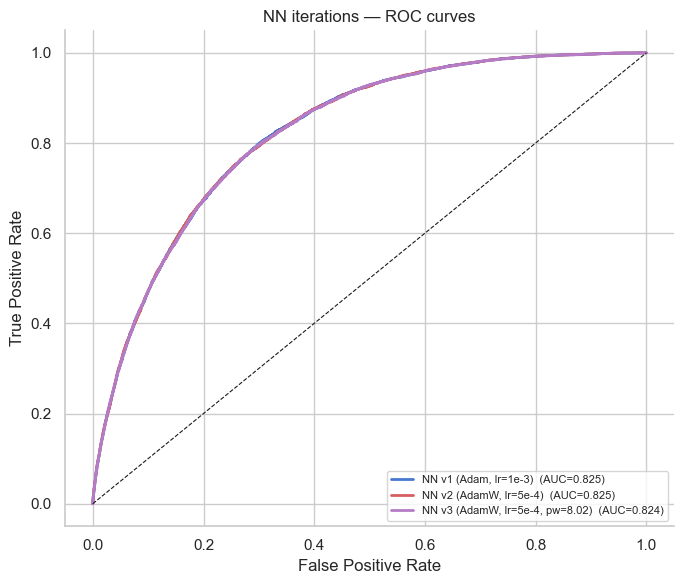

NN iteration comparison:
                                 Accuracy  Precision (diab.)  Recall (diab.)  F1 (diab.)  ROC-AUC
Model                                                                                            
NN v1 (Adam, lr=1e-3)              0.7216             0.3365          0.7889      0.4717   0.8249
NN v2 (AdamW, lr=5e-4)             0.7209             0.3355          0.7864      0.4703   0.8250
NN v3 (AdamW, lr=5e-4, pw=8.02)    0.6604             0.2988          0.8578      0.4432   0.8244


In [124]:
nn_versions = [
    ("NN v1 (Adam, lr=1e-3)",                      nn_probs,    nn_preds),
    ("NN v2 (AdamW, lr=5e-4)",                     nn_v2_probs, nn_v2_preds),
    (f"NN v3 (AdamW, lr=5e-4, pw={best_pw})",      nn_v3_probs, nn_v3_preds),
]

# Overlaid ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
colors_nn = ["#4878cf", "#d65f5f", "#b47cc7"]
for (name, probs, _), color in zip(nn_versions, colors_nn):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name}  (AUC={auc:.3f})", color=color)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("NN iterations — ROC curves", fontsize=12)
ax.legend(loc="lower right", fontsize=8)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "22_nn_iterations_roc.png", bbox_inches="tight", dpi=150)
plt.show()

# Summary table — include recall explicitly for the diabetes class
nn_rows = []
for name, probs, preds in nn_versions:
    nn_rows.append({
        "Model":              name,
        "Accuracy":           accuracy_score(y_test, preds),
        "Precision (diab.)":  precision_score(y_test, preds, zero_division=0),
        "Recall (diab.)":     recall_score(y_test, preds),
        "F1 (diab.)":         f1_score(y_test, preds),
        "ROC-AUC":            roc_auc_score(y_test, probs),
    })

nn_summary = pd.DataFrame(nn_rows).set_index("Model")
print("NN iteration comparison:")
print(nn_summary.round(4).to_string())